<a href="https://colab.research.google.com/github/e23046/Statistical-Learning-e23046/blob/main/Assignment%202/Q4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Answer For Question 04

## Problem: Beta Distribution for Defective Items

In a manufacturing process, the proportion of defective items in a large batch produced on a given day is modeled by a continuous random variable $X$. Since $X$ represents a proportion, it takes values in the interval $[0,1]$. Suppose that $X$ has a Beta distribution with parameters $\alpha=2$ and $\beta=18$, so that its density is

$$
f(x)=\begin{cases}
\dfrac{1}{B(2,18)}x^{1}(1-x)^{17}, & 0<x<1,\\
0, & \text{otherwise},
\end{cases}
$$

where $B(2,18)$ is the Beta function.

Answer the following:

1.  Construct a probability space $(\Omega,\mathfrak F,P)$ suitable for this model.
2.  Define $X$ as a continuous random variable on this space.
3.  Write down the probability density function of $X$.
4.  Verify that $f$ is a valid probability density function.
5.  Compute the expectation $E[X]$.
6.  Compute the variance $\mathrm{Var}(X)$.
7.  Find the probability that the defective proportion is at most $0.10$, that is, compute $P(X\le 0.10)$. You may leave your answer in Beta integral form.
8.  Find the probability that the defective proportion lies between $0.05$ and $0.15$, that is, compute $P(0.05\le X\le 0.15)$. You may leave your answer in integral form.
9.  Briefly explain why a Beta distribution is a reasonable model for this situation.
10. Interpret the expectation and variance in the context of production quality.

### Solution

First, let's import the necessary libraries.

In [1]:
import numpy as np
from scipy.stats import beta
from scipy.special import beta as beta_func

alpha = 2
beta_param = 18

---

#### 1. Construct a probability space $(\Omega,\mathfrak F,P)$ suitable for this model.

-   **Sample Space $\Omega$**: The set of all possible outcomes. In this case, $\Omega = [0, 1]$, representing all possible proportions of defective items.
-   **Sigma-algebra $\mathfrak F$**: A collection of subsets of $\Omega$ that includes $\Omega$ itself, is closed under complementation, and is closed under countable unions. For continuous random variables, this is typically the Borel \$\sigma\$-algebra on $[0,1]$, denoted $\mathcal{B}([0,1])$. This includes all intervals, open sets, closed sets, and countable unions/intersections thereof within $[0,1]$.
-   **Probability Measure $P$**: A function that assigns probabilities to events in $\mathfrak F$. For a continuous random variable with a given probability density function $f(x)$, the probability of an event $A \in \mathfrak F$ is given by $P(A) = \int_A f(x) dx$.

So, the probability space is $(\Omega, \mathfrak F, P) = ([0, 1], \mathcal{B}([0,1]), P)$, where $P(A) = \int_A \frac{1}{B(2,18)}x^{1}(1-x)^{17} dx$.

---

#### 2. Define $X$ as a continuous random variable on this space.

A random variable $X$ is a function $X: \Omega \to \mathbb{R}$ that maps outcomes from the sample space to real numbers. For a continuous random variable, this function is measurable with respect to $\mathfrak F$ and the Borel \$\sigma\$-algebra on $\mathbb{R}$.

In this model, $X$ is the proportion of defective items, and its values are in $[0,1]$. So, $X$ is a continuous random variable on the probability space $([0, 1], \mathcal{B}([0,1]), P)$ such that $X(\omega) = \omega$ for $\omega \in [0,1]$.

---

#### 3. Write down the probability density function of $X$.

The probability density function (PDF) of $X$ is given directly in the problem description:

$$
f(x)=\begin{cases}
\dfrac{1}{B(2,18)}x^{1}(1-x)^{17}, & 0<x<1,\\
0, & \text{otherwise},
\end{cases}
$$

where $B(2,18)$ is the Beta function, defined as $B(\alpha, \beta) = \frac{\Gamma(\alpha)\Gamma(\beta)}{\Gamma(\alpha+\beta)}$. For this specific case, $B(2,18) = \frac{\Gamma(2)\Gamma(18)}{\Gamma(2+18)} = \frac{1! 17!}{19!}$.

---

#### 4. Verify that $f$ is a valid probability density function.

For $f(x)$ to be a valid PDF, two conditions must be met:
1.  $f(x) \ge 0$ for all $x \in \mathbb{R}$.
2.  $\int_{-\infty}^{\infty} f(x) dx = 1$.

For $0 < x < 1$, $x^1 > 0$ and $(1-x)^{17} > 0$. The Beta function $B(2,18)$ is a positive constant. Thus, $f(x) \ge 0$ for all $x$. Outside $(0,1)$, $f(x) = 0$, so $f(x) \ge 0$ is satisfied.

The second condition requires that the integral of the PDF over its entire domain is 1. By definition of the Beta distribution, its PDF integrates to 1 over $[0,1]$. We can confirm this using `scipy.stats.beta`.

In [2]:
# The Beta function B(alpha, beta) is the normalizing constant for the Beta distribution.
# Its purpose is to ensure that the integral of the PDF over [0,1] is equal to 1.
# So, by definition of the Beta distribution, the integral is 1.
# We can demonstrate this by numerically integrating or by using the CDF over the entire range.

# Using scipy.stats.beta.cdf to show the integral from 0 to 1 is 1
integral_value = beta.cdf(1, a=alpha, b=beta_param) - beta.cdf(0, a=alpha, b=beta_param)
print(f"Integral of f(x) from -inf to inf (or 0 to 1 for Beta distribution): {integral_value}")

# Also confirm f(x) >= 0 for 0 < x < 1
# We know alpha, beta > 0, so x^(alpha-1) and (1-x)^(beta-1) are positive for x in (0,1).
# B(alpha, beta) is also positive. So f(x) is positive for x in (0,1) and 0 otherwise.

Integral of f(x) from -inf to inf (or 0 to 1 for Beta distribution): 1.0


---

#### 5. Compute the expectation $E[X]$.

For a Beta distribution with parameters $\alpha$ and $\beta$, the expectation $E[X]$ is given by the formula:

$$ E[X] = \frac{\alpha}{\alpha + \beta} $$

Given $\alpha=2$ and $\beta=18$:

In [3]:
expectation_X = alpha / (alpha + beta_param)
print(f"E[X] = {expectation_X}")

E[X] = 0.1


---

#### 6. Compute the variance $\mathrm{Var}(X)$.

For a Beta distribution with parameters $\alpha$ and $\beta$, the variance $\mathrm{Var}(X)$ is given by the formula:

$$ \mathrm{Var}(X) = \frac{\alpha\beta}{(\alpha + \beta)^2 (\alpha + \beta + 1)} $$

Given $\alpha=2$ and $\beta=18$:

In [4]:
variance_X = (alpha * beta_param) / ((alpha + beta_param)**2 * (alpha + beta_param + 1))
print(f"Var(X) = {variance_X}")

Var(X) = 0.004285714285714286


---

#### 7. Find the probability that the defective proportion is at most $0.10$, that is, compute $P(X\le 0.10)$. You may leave your answer in Beta integral form.

This is equivalent to finding the cumulative distribution function (CDF) at $x=0.10$. The CDF $F(x)$ for a Beta distribution is given by the regularized incomplete Beta function, denoted $I_x(\alpha, \beta)$.

$$ P(X\le 0.10) = \int_0^{0.10} \frac{1}{B(2,18)}x^{1}(1-x)^{17} dx $$

We can compute this using `scipy.stats.beta.cdf`.

In [5]:
prob_at_most_0_10 = beta.cdf(0.10, a=alpha, b=beta_param)
print(f"P(X <= 0.10) = {prob_at_most_0_10}")

P(X <= 0.10) = 0.5797350211684026


---

#### 8. Find the probability that the defective proportion lies between $0.05$ and $0.15$, that is, compute $P(0.05\le X\le 0.15)$. You may leave your answer in integral form.

This probability can be calculated as the difference between the CDFs at $0.15$ and $0.05$:

$$ P(0.05\le X\le 0.15) = P(X\le 0.15) - P(X\le 0.05) = \int_{0.05}^{0.15} \frac{1}{B(2,18)}x^{1}(1-x)^{17} dx $$

We can compute this using `scipy.stats.beta.cdf`.

In [6]:
prob_between_0_05_and_0_15 = beta.cdf(0.15, a=alpha, b=beta_param) - beta.cdf(0.05, a=alpha, b=beta_param)
print(f"P(0.05 <= X <= 0.15) = {prob_between_0_05_and_0_15}")

P(0.05 <= X <= 0.15) = 0.5562154887900577


---

#### 9. Briefly explain why a Beta distribution is a reasonable model for this situation.

The Beta distribution is a reasonable model for the proportion of defective items for several key reasons:

1.  **Defined on a Bounded Interval:** The Beta distribution is naturally defined on the interval $[0,1]$, which perfectly matches the domain for a proportion (percentages or fractions of a whole). A proportion cannot be less than 0 or greater than 1.
2.  **Flexibility in Shape:** With its two positive shape parameters ($\alpha$ and $\beta$), the Beta distribution can take on a wide variety of shapes, including uniform, U-shaped, J-shaped, and bell-shaped curves. This flexibility allows it to model various underlying processes for proportions, reflecting different beliefs or observed patterns in the data. In this case, with $\alpha=2$ and $\beta=18$, the distribution is skewed heavily towards lower proportions, suggesting that a low proportion of defective items is more common, which is desirable in manufacturing.
3.  **Conjugate Prior in Bayesian Statistics:** While not explicitly used in this problem, the Beta distribution is also a conjugate prior for the Bernoulli and Binomial distributions. This makes it very convenient in Bayesian contexts for updating beliefs about a true underlying proportion based on observed data.

---

#### 10. Interpret the expectation and variance in the context of production quality.

-   **Expectation $E[X]$:** The expectation represents the *average* or *mean* proportion of defective items expected in a large batch over many production days. Our calculation showed $E[X] = 0.10$. This means that, on average, we expect 10% of the items produced to be defective. This serves as a central tendency measure for the process's defect rate.

-   **Variance $\mathrm{Var}(X)$:** The variance quantifies the *spread* or *variability* in the proportion of defective items from day to day. A small variance indicates that the proportion of defective items is consistently close to the mean (0.10), meaning the production process is stable in its defect rate. A large variance would imply that the defect rate fluctuates significantly, with some days having very low defective proportions and others having very high ones. Our calculated variance of approximately 0.0043 suggests a relatively small spread around the mean, indicating that the defect rate is likely to be consistently around 10%.

---

### The plot of the $\beta$-distribution

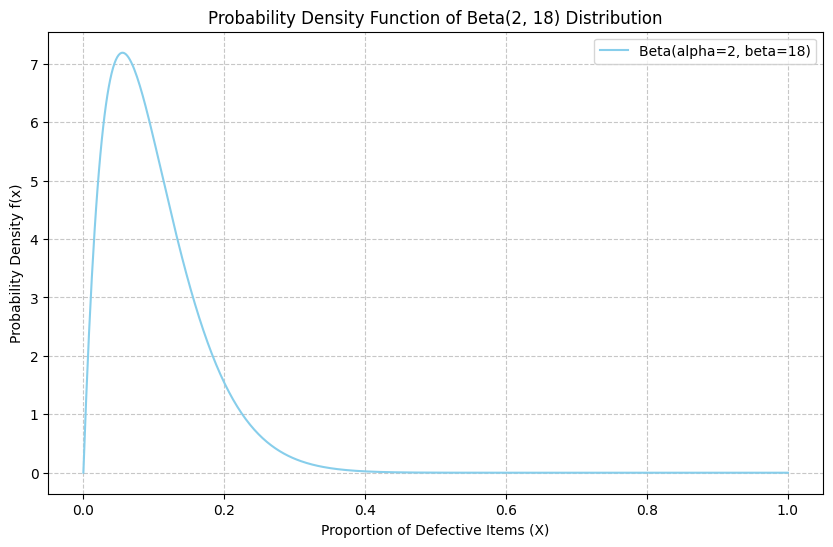

In [7]:
import matplotlib.pyplot as plt

# Generate x values from 0 to 1
x = np.linspace(0, 1, 500)

# Calculate the PDF for each x value
pdf_values = beta.pdf(x, a=alpha, b=beta_param)

# Plot the PDF
plt.figure(figsize=(10, 6))
plt.plot(x, pdf_values, label=f'Beta(alpha={alpha}, beta={beta_param})', color='skyblue')
plt.title('Probability Density Function of Beta(2, 18) Distribution')
plt.xlabel('Proportion of Defective Items (X)')
plt.ylabel('Probability Density f(x)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()